# Model selection rationale

We selected three supervised learning algorithms for this classification task:
Logistic Regression, Random Forest, and Support Vector Machine (SVM).

**Logistic Regression** was chosen as a baseline model because it is simple, fast, and interpretable. </br>
**Random Forest** was selected because it can capture non-linear relationships, handle complex feature interactions, and provide feature importance. </br>
**SVM** was chosen because it performs well in classification problems and can handle high-dimensional data effectively. </br> </br>

These models represent different learning approaches, which makes the comparison more meaningful and helps identify the most suitable model for predicting student depression risk.

In [4]:
#Implementation & training code
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# Load dataset
df = pd.read_csv('clean_data.csv')

# Features and target
X = df.drop('Depression', axis=1)
y = df['Depression']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features AFTER splitting to prevent data leakage.
# The scaler is fitted on X_train only, then applied to both sets.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Support Vector Machine (class_weight='balanced' handles the 9:1 class imbalance)
svm = LinearSVC(class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("Training completed successfully.")

Logistic Regression Accuracy: 0.639518341631948
Random Forest Accuracy: 0.9002642007926024
Training completed successfully.


The Logistic Regression model was evaluated using accuracy, confusion matrix, and classification report.
After applying class_weight='balanced', the model achieved an accuracy of approximately 64%.

The results indicate that the model is able to detect both classes, including the minority class (depressed students).
The recall for the depressed class improved significantly, showing that the model can correctly identify a large portion of positive cases.

However, the precision for the depressed class remains relatively low, meaning that the model produces a noticeable number of false positives.
This trade-off is expected when dealing with imbalanced datasets, where improving recall often reduces precision.

Overall, Logistic Regression provides a reasonable baseline model for this classification task.
While it successfully captures general patterns in the data, more advanced models may achieve better performance and a stronger balance between precision and recall.

Hyperparameter tuning was not applied to Logistic Regression in this project
because it was used as a baseline model. The default parameters already provided
strong performance, and the goal was to compare it with more complex models
such as Random Forest and SVM, where tuning has a greater impact.

# Hyperparameter tuning process & result

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Random Forest tuning
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = grid_rf.best_estimator_.predict(X_test)

print("Best Random Forest Parameters:", grid_rf.best_params_)
print("Random Forest Accuracy after tuning:", accuracy_score(y_test, y_pred_rf))

# SVM tuning
# cv=5 matches the k-fold strategy used across all models.
param_grid_svm = {
    'C': [0.1, 1, 10]
}

grid_svm = GridSearchCV(
    LinearSVC(class_weight='balanced', random_state=42, max_iter=5000),
    param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

print("Best LinearSVC Parameters:", grid_svm.best_params_)
print("SVM Accuracy after tuning:", accuracy_score(y_test, y_pred_svm))

Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest Accuracy after tuning: 0.7437760390204248
Best LinearSVC Parameters: {'C': 1}
SVM Accuracy after tuning: 0.6385529925820547


# Evaluation metrics & visualizations

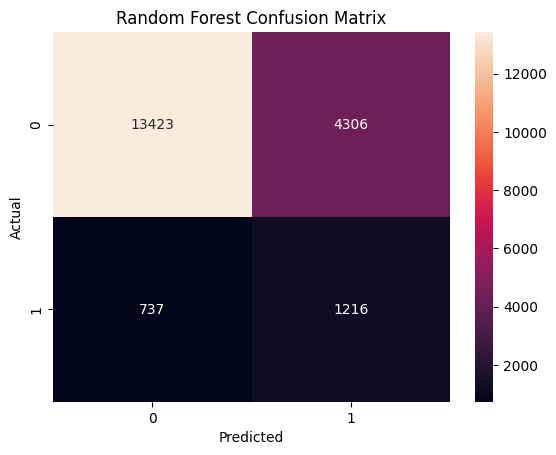

Random Forest Classification Report:

              precision    recall  f1-score   support

       False       0.95      0.76      0.84     17729
        True       0.22      0.62      0.33      1953

    accuracy                           0.74     19682
   macro avg       0.58      0.69      0.58     19682
weighted avg       0.88      0.74      0.79     19682



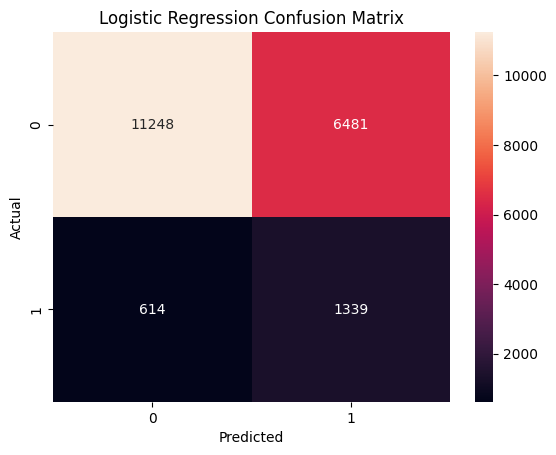

Logistic Regression Classification Report:

              precision    recall  f1-score   support

       False       0.95      0.63      0.76     17729
        True       0.17      0.69      0.27      1953

    accuracy                           0.64     19682
   macro avg       0.56      0.66      0.52     19682
weighted avg       0.87      0.64      0.71     19682



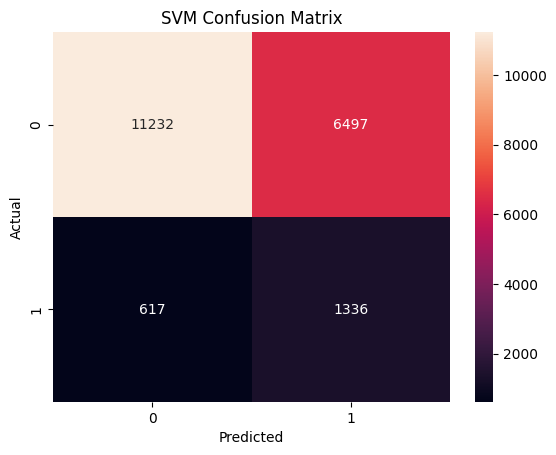

SVM Classification Report:

              precision    recall  f1-score   support

       False       0.95      0.63      0.76     17729
        True       0.17      0.68      0.27      1953

    accuracy                           0.64     19682
   macro avg       0.56      0.66      0.52     19682
weighted avg       0.87      0.64      0.71     19682


   5-FOLD CROSS-VALIDATION RESULTS
Logistic Regression CV Accuracy : 0.6356 (+/- 0.0043)
SVM (LinearSVC)     CV Accuracy : 0.6342 (+/- 0.0046)
Random Forest       CV Accuracy : 0.7393 (+/- 0.0030)


Random Forest ROC-AUC Score: 0.6994
Note: ROC-AUC is not reported for LinearSVC because it does not
      support probability estimates (no predict_proba method).




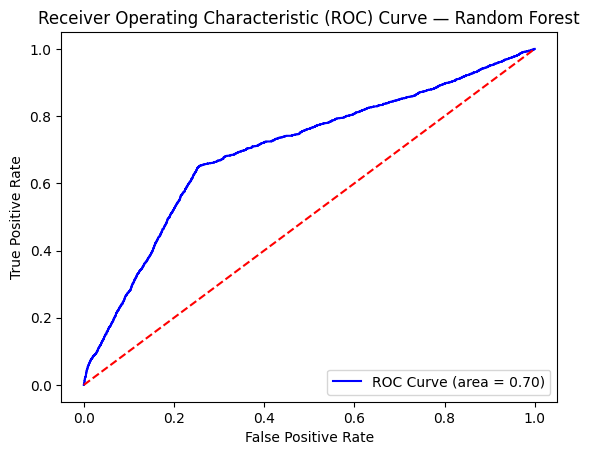

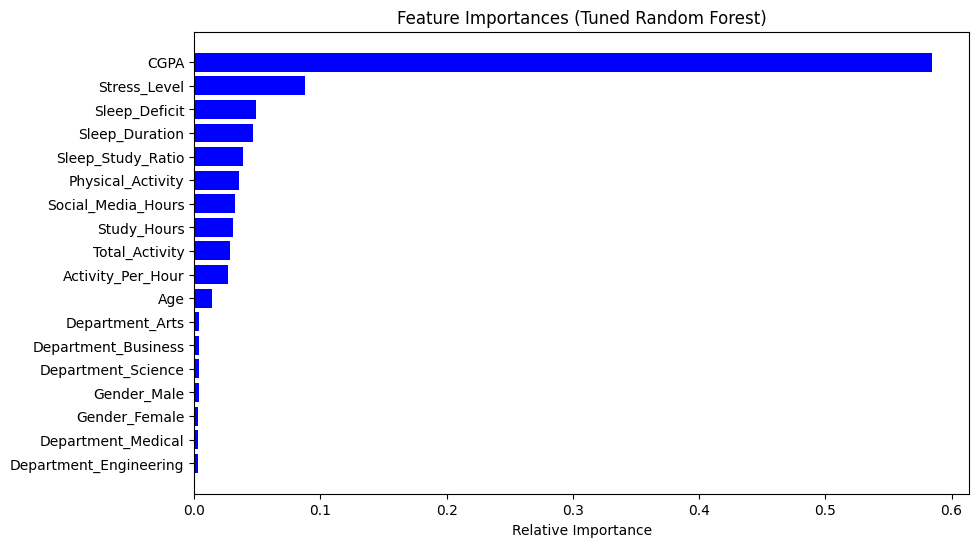

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Confusion Matrix & Classification Reports
cm     = confusion_matrix(y_test, y_pred_lr)
cm_rf  = confusion_matrix(y_test, y_pred_rf)
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Random Forest
plt.figure()
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Logistic Regression
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

# SVM
plt.figure()
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))


# K-Fold Cross Validation (k=5) applied to all three models
# All three pipelines wrap StandardScaler so the scaler is re-fitted
# inside each fold on that fold's training split only.
# All three use the same full dataset (X, y) for a fair, comparable result.
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

print("\n" + "=" * 50)
print("   5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 50)

# Reconstruct pipelines using the same hyperparameters as the tuned models
pipe_lr  = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
pipe_svm = make_pipeline(StandardScaler(), LinearSVC(C=best_svm.C, class_weight='balanced', random_state=42, max_iter=5000))
pipe_rf  = make_pipeline(StandardScaler(), RandomForestClassifier( n_estimators=best_rf.n_estimators, max_depth=best_rf.max_depth, min_samples_split=best_rf.min_samples_split, class_weight='balanced', random_state=42))

cv_scores_lr  = cross_val_score(pipe_lr,  X, y, cv=5, scoring='accuracy')
cv_scores_svm = cross_val_score(pipe_svm, X, y, cv=5, scoring='accuracy')
cv_scores_rf  = cross_val_score(pipe_rf,  X, y, cv=5, scoring='accuracy')

print(f"Logistic Regression CV Accuracy : {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std() * 2:.4f})")
print(f"SVM (LinearSVC)     CV Accuracy : {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std() * 2:.4f})")
print(f"Random Forest       CV Accuracy : {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")

# ROC-AUC، Random Forest only
# LinearSVC does not support predict_proba(), so ROC-AUC is only
# computed for models that provide probability estimates.
print("\n")
y_pred_prob_rf = best_rf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob_rf)
print(f"Random Forest ROC-AUC Score: {roc_auc:.4f}")
print("Note: ROC-AUC is not reported for LinearSVC because it does not")
print("      support probability estimates (no predict_proba method).")
print("\n")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_rf)
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve — Random Forest')
plt.legend(loc="lower right")
plt.show()


# Feature Importance Plot
print("\n")
importances = best_rf.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Tuned Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


We conduct a detailed evaluation of the models using various performance metrics and validation techniques. The goal is to assess the models' ability to identify at-risk students and to ensure the stability of the results across different data subsets.

1. **Evaluation Metrics & Confusion Matrix:**
We utilized several metrics, including Accuracy, Precision, Recall, and the F1-Score. Given the class imbalance in our dataset, the F1-Score and Recall for the positive class (Depressed) were given significant attention to better understand how the models handle the minority class.

Confusion Matrix heatmaps were generated for each model to visualize the distribution of True Positives, True Negatives, False Positives, and False Negatives.

2. **K-Fold Cross-Validation (k=5):**
To verify the consistency of the results, we applied a 5-fold cross-validation (k=5) approach to **all three models**. For Logistic Regression and SVM, cross-validation is performed inside a `Pipeline` that re-fits the `StandardScaler` on each fold's training data, ensuring that the validation estimate is free from data leakage. This process splits the dataset into five subsets and trains the model five times to ensure performance is not biased by a specific train-test split.

3. **ROC-AUC Analysis:**
ROC-AUC is computed and plotted for the **Random Forest** model only. `LinearSVC` does not expose probability estimates (`predict_proba` is unavailable), so a valid ROC-AUC score cannot be computed for the SVM. The Random Forest ROC-AUC score reflects its overall ability to distinguish between students at risk of depression and those who are not.

4. **Feature Importance:**
To enhance the interpretability of our findings, we extracted the Feature Importance values from the tree-based model. This allows us to identify which variables contribute most to the model's predictions. According to the generated plot, CGPA and Stress Level emerged as the most influential factors.

# model comparison & analysis

In this section, we compare the performance of the three implemented models based on accuracy, error patterns, and system trade-offs.

**1. Performance Comparison (Which model performed best?)**
| Evaluation Metric | Random Forest (Tuned) | Logistic Regression | SVM (Linear) |
| :--- | :--- | :--- | :--- |
| **Test Accuracy** | **74.38%** | 63.95% | 63.86% |
| **5-Fold CV Accuracy** | **73.93% ± 0.30%** | 63.56% ± 0.43% | 63.42% ± 0.46% |
| **ROC-AUC Score** | **0.70** | N/A | N/A — LinearSVC has no `predict_proba` |
| **F1-Score (Positive class)** | **0.33** | 0.27 | 0.27 |
| **Recall (Positive class)** | **0.62** | 0.69 | 0.68 |

> **Note on ROC-AUC for SVM:** `LinearSVC` does not implement `predict_proba()`, so a ROC-AUC score cannot be derived from it directly. Only the Random Forest provides this metric. This is a known limitation of the linear SVM variant and is accounted for in the comparative analysis below.

The **Random Forest** model performed the best across all metrics. It successfully captured the complex, non-linear relationships in the student data, whereas the linear models (LR and SVM) struggled to separate the classes effectively.

**2. Misclassification Analysis (Patterns & Challenging Categories)**
Despite applying class weights, all models produced a noticeable number of False Positives (predicting a student is depressed when they are not). The primary reason for this pattern is the overlapping nature of the features. High academic pressure, low sleep duration, and study-related stress are common among university students. While these factors strongly correlate with depression, they do not always equate to a clinical diagnosis. The models sometimes struggle to differentiate between a "highly stressed student" and a "depressed student," making this the most challenging category to classify perfectly.

**3. Discussing Trade-offs (Accuracy vs. Interpretability vs. Cost)**
* **Logistic Regression & SVM:** These models offer extremely low computational cost and are highly interpretable (via direct coefficients). However, the trade-off is a significant drop in accuracy and recall for the positive class, making them inadequate for our goal.
* **Random Forest:** As an ensemble method, it has a slightly higher computational cost and longer training time compared to linear models. However, for a dataset of this size, the cost is negligible. It offers significantly higher accuracy and maintains strong interpretability through its Feature Importance metric, making the trade-off highly beneficial.

# conclusion :best model selection & reasoning

Based on the comparative analysis, our final recommendation is to utilize the **Random Forest** model for the predictive system.

We selected this model due to the following reasons:
1. **Best Handling of Imbalanced Data:** In predictive systems for well-being, maximizing Recall (minimizing False Negatives) is critical to ensure no at-risk individual is missed. Random Forest provided the highest F1-score (0.33) for the depressed class and a recall of 0.62, correctly identifying the majority of at-risk students.
2. **Optimal Balance of Trade-offs:** It provides the perfect middle ground—delivering superior predictive accuracy without completely sacrificing interpretability. The slight increase in computational cost is easily manageable for modern deployment environments.
3. **Actionable Insights:** Since the Random Forest clearly identified **CGPA** and **Stress_Level** as the most critical predictors, the system can use this specific information to provide targeted, personalized interventions, directly fulfilling the core analytical objective of this project.

# next step for phase 2 integration


Having successfully completed Phase 1 by training, evaluating, and selecting the optimal Random Forest model for our system, we are now prepared to transition to Phase 2. The next phase will focus on moving beyond basic supervised predictions to generate deeper insights and provide user-friendly interactions.

Based on the project requirements, our integration plan for Phase 2 includes:

**1. Unsupervised Learning (Clustering) Integration:**
We will apply unsupervised learning techniques to our dataset (after removing the class labels) to uncover hidden patterns within the student data. We plan to implement and compare at least two clustering algorithms. By evaluating these clusters (using metrics like the Silhouette Score and WCSS), we aim to profile different student groups and formulate a strategy on how these clusters can further enhance the accuracy and context of our supervised model's suggestions.

**2. Generative AI (GAI) Integration:**
To elevate the system from merely predicting a risk level to actively providing personalized and detailed advice, we will integrate a Generative AI model (such as LLaMA, GPT, or via the Bard API). This integration will involve designing and rigorously testing four distinct prompt templates. These templates will combine the user's data and the Random Forest model's output to generate clear, safe, and context-aware explanations and recommendations for the students.

By combining the robust predictive power of the Random Forest model (Phase 1) with the pattern discovery of clustering and the explanatory capabilities of Generative AI (Phase 2), we will deliver a comprehensive and intelligent advice system.